<a href="https://colab.research.google.com/github/Danny3636/Generative-AI-Tasks/blob/main/Required_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

From this code, I've learned that normal messages are slightly more positive than spam, with similar subjectivity. More importantly, topic modeling revealed that 'General/Conversational' and 'Politics/News' content are significantly more prone to being spam. This information can be used to improve spam detection by developing filters that specifically target linguistic patterns within these high-risk topics, potentially by integrating sentiment and topic features into a machine learning classification model.

# Task
Load the "fakenews.csv" dataset, perform sentiment analysis on the 'text' column to compare sentiment between spam and normal messages, conduct topic modeling on the 'text' column, and analyze the relationship between the identified topics and spam labels. Finally, summarize the findings from both sentiment analysis and topic modeling.

In [19]:
import pandas as pd
df = pd.read_csv('/content/sample_data/fakenews.csv')
print(df.head())

                                                text label Unnamed: 2  \
0  Get the latest from TODAY Sign up for our news...     1        NaN   
1  2d  Conan On The Funeral Trump Will Be Invited...     1        NaN   
2  It’s safe to say that Instagram Stories has fa...     0        NaN   
3  Much like a certain Amazon goddess with a lass...     0        NaN   
4  At a time when the perfect outfit is just one ...     0        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9  ... Unnamed: 417 Unnamed: 418 Unnamed: 419 Unnamed: 420  \
0        NaN  ...          NaN          NaN          NaN     

/tmp/ipykernel_2159/581283261.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,2

In [20]:
import pandas as pd
df = pd.read_csv('/content/sample_data/fakenews.csv', low_memory=False)
print(df.head())

                                                text label Unnamed: 2  \
0  Get the latest from TODAY Sign up for our news...     1        NaN   
1  2d  Conan On The Funeral Trump Will Be Invited...     1        NaN   
2  It’s safe to say that Instagram Stories has fa...     0        NaN   
3  Much like a certain Amazon goddess with a lass...     0        NaN   
4  At a time when the perfect outfit is just one ...     0        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9  ... Unnamed: 417 Unnamed: 418 Unnamed: 419 Unnamed: 420  \
0        NaN  ...          NaN          NaN          NaN     

In [21]:
try:
    from textblob import TextBlob
    print("TextBlob is already installed.")
except ImportError:
    print("Installing TextBlob...")
    !pip install textblob
    from textblob import TextBlob
    print("TextBlob installed successfully.")


TextBlob is already installed.


In [22]:
from textblob import TextBlob

# Handle missing values in 'text' column
df['text'] = df['text'].fillna('')

# Function to get sentiment scores
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

# Apply the function to the 'text' column
df['polarity'], df['subjectivity'] = zip(*df['text'].apply(get_sentiment))

print("Sentiment analysis complete. Added 'polarity' and 'subjectivity' columns to the DataFrame.")
print(df[['text', 'polarity', 'subjectivity']].head())

Sentiment analysis complete. Added 'polarity' and 'subjectivity' columns to the DataFrame.
                                                text  polarity  subjectivity
0  Get the latest from TODAY Sign up for our news...  0.189989      0.479679
1  2d  Conan On The Funeral Trump Will Be Invited...  0.000000      0.000000
2  It’s safe to say that Instagram Stories has fa...  0.230229      0.512582
3  Much like a certain Amazon goddess with a lass...  0.133501      0.413743
4  At a time when the perfect outfit is just one ...  0.107985      0.542483


In [23]:
print(df['label'].unique())
print(df['label'].value_counts())

['1' '0' nan
 ' she has said.[188] Although stopping short of an endorsement'
 ' the lieutenant finally notices that their orders were never officially signed by the master-at-arms in Norfolk'
 ' And Always Will Be'
 ' so they felt she should be the one moved off the pole'
 ' a child advocacy and research group.[166] In 2006'
 '000 hectares and turned the area into a wildlife reserve named for her son'
 ' Ms Guerrero said she brought a female casting director with her.  She said Mr Seagal answered the door in a silk robe and although he never exposed himself to her or touched her']
label
0                                                                                                                                                                                     2925
1                                                                                                                                                                                     1971
000 hectares and turned the are

In [24]:
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

print("Cleaned 'label' column. Now showing unique values and counts:")
print(df['label'].unique())
print(df['label'].value_counts())

Cleaned 'label' column. Now showing unique values and counts:
[1 0]
label
0    2925
1    1971
Name: count, dtype: int64


In [25]:
sentiment_comparison = df.groupby('label')[['polarity', 'subjectivity']].mean()
print("Average sentiment scores per label category:")
print(sentiment_comparison)

Average sentiment scores per label category:
       polarity  subjectivity
label                        
0      0.148842      0.446889
1      0.114848      0.447963


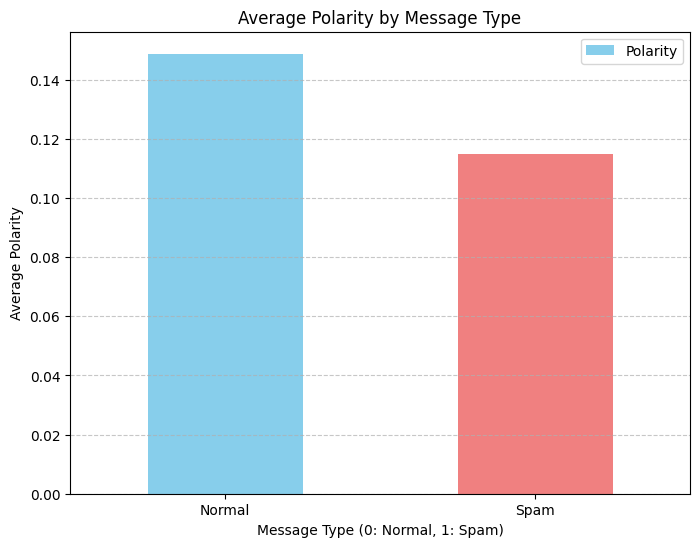

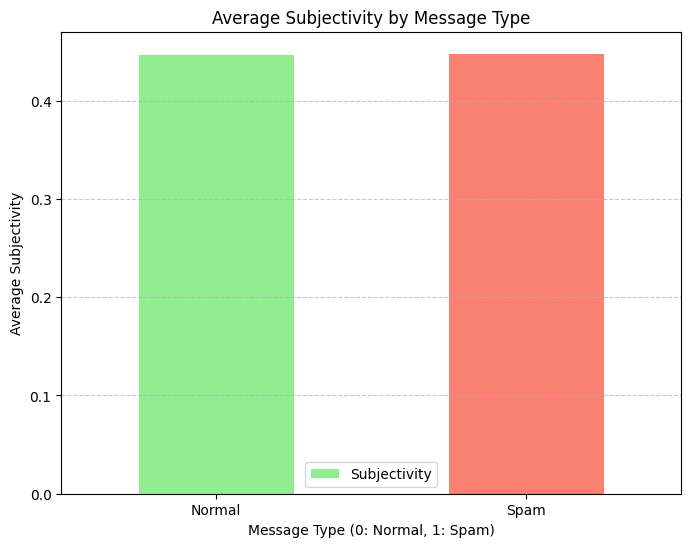

In [26]:
import matplotlib.pyplot as plt

# Create a bar plot for average polarity
plt.figure(figsize=(8, 6))
sentiment_comparison['polarity'].plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Average Polarity by Message Type')
plt.xlabel('Message Type (0: Normal, 1: Spam)')
plt.ylabel('Average Polarity')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Spam'], rotation=0)
plt.legend(['Polarity'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Create a bar plot for average subjectivity
plt.figure(figsize=(8, 6))
sentiment_comparison['subjectivity'].plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Average Subjectivity by Message Type')
plt.xlabel('Message Type (0: Normal, 1: Spam)')
plt.ylabel('Average Subjectivity')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Spam'], rotation=0)
plt.legend(['Subjectivity'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK libraries imported and resources downloaded.")

NLTK libraries imported and resources downloaded.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [18]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab', quiet=True) # Download missing resource

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Convert to lowercase and remove non-alphabetic characters
    tokens = [word.lower() for word in tokens if word.isalpha()]
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # Join tokens back into a string
    return ' '.join(tokens)

# Apply the preprocessing function to the 'text' column
df['processed_text'] = df['text'].apply(preprocess_text)

print("Text preprocessing complete. Displaying original and processed text:")
print(df[['text', 'processed_text']].head())

Text preprocessing complete. Displaying original and processed text:
                                                text  \
0  Get the latest from TODAY Sign up for our news...   
1  2d  Conan On The Funeral Trump Will Be Invited...   
2  It’s safe to say that Instagram Stories has fa...   
3  Much like a certain Amazon goddess with a lass...   
4  At a time when the perfect outfit is just one ...   

                                      processed_text  
0  get latest today sign newsletter one ever trul...  
1               conan funeral trump invited conan tb  
2  safe say instagram story far surpassed competi...  
3  much like certain amazon goddess lasso height ...  
4  time perfect outfit one click away high demand...  


In [33]:
from sklearn.feature_extraction.text import CountVectorizer

# Check if 'processed_text' column exists, if not, re-run preprocessing steps
if 'processed_text' not in df.columns:
    print("WARNING: 'processed_text' column not found. Re-running text preprocessing steps.")
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    from nltk.tokenize import word_tokenize

    # Ensure NLTK resources are downloaded, quiet=True to suppress repeated messages
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    nltk.download('punkt_tab', quiet=True) # Ensure this specific one is downloaded

    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    def preprocess_text(text):
        if not isinstance(text, str):
            text = str(text) # Convert to string if not already
        tokens = word_tokenize(text)
        tokens = [word.lower() for word in tokens if word.isalpha()]
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
        return ' '.join(tokens)

    # Apply preprocessing if column doesn't exist
    df['processed_text'] = df['text'].apply(preprocess_text)
    print("'processed_text' column created.")

# Initialize CountVectorizer
vectorizer = CountVectorizer(
    max_df=0.95, min_df=2, stop_words='english'
)

# Fit and transform the processed text to create the document-term matrix
doc_term_matrix = vectorizer.fit_transform(df['processed_text'])

print("Document-term matrix created. Shape: ", doc_term_matrix.shape)

Document-term matrix created. Shape:  (4896, 26485)


In [34]:
from sklearn.decomposition import LatentDirichletAllocation

# Initialize LDA model with 5 topics and a random state for reproducibility
n_components = 5
lda = LatentDirichletAllocation(n_components=n_components, random_state=42)

# Fit the LDA model to the document-term matrix
lda.fit(doc_term_matrix)

# Assign topic labels to each document
df['topic_label'] = lda.transform(doc_term_matrix).argmax(axis=1)

print(f"LDA model fitted with {n_components} topics. Topic labels added to DataFrame.")

# Function to print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = "Topic #%d: " % topic_idx
        message += " ".join([feature_names[i]
                                for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# Get feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Print the top 10 words for each topic
n_top_words = 10
print(f"\nTop {n_top_words} words per topic:")
print_top_words(lda, feature_names, n_top_words)

LDA model fitted with 5 topics. Topic labels added to DataFrame.

Top 10 words per topic:
Topic #0: new season song album music selena award justin year bieber
Topic #1: family said harry kardashian wedding prince kim meghan royal time
Topic #2: trump said president year people state new time woman news
Topic #3: film series season role best award movie actress actor year
Topic #4: like time said year say know love people thing want


In [32]:
from sklearn.decomposition import LatentDirichletAllocation

# Initialize LDA model with 5 topics and a random state for reproducibility
n_components = 5
lda = LatentDirichletAllocation(n_components=n_components, random_state=42)

# Fit the LDA model to the document-term matrix
lda.fit(doc_term_matrix)

# Assign topic labels to each document
df['topic_label'] = lda.transform(doc_term_matrix).argmax(axis=1)

print(f"LDA model fitted with {n_components} topics. Topic labels added to DataFrame.")

# Function to print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_): # Corrected from model.components__
        message = "Topic #%d: " % topic_idx
        message += " ".join([feature_names[i]
                                for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# Get feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Print the top 10 words for each topic
n_top_words = 10
print(f"\nTop {n_top_words} words per topic:")
print_top_words(lda, feature_names, n_top_words)

LDA model fitted with 5 topics. Topic labels added to DataFrame.

Top 10 words per topic:
Topic #0: new season song album music selena award justin year bieber
Topic #1: family said harry kardashian wedding prince kim meghan royal time
Topic #2: trump said president year people state new time woman news
Topic #3: film series season role best award movie actress actor year
Topic #4: like time said year say know love people thing want


In [35]:
topic_spam_counts = df.groupby(['topic_label', 'label']).size().unstack(fill_value=0)
print("Topic-Spam Counts:")
print(topic_spam_counts)

Topic-Spam Counts:
label          0    1
topic_label          
0            363  109
1            829  470
2            412  375
3            470  164
4            851  853


<Figure size 1000x600 with 0 Axes>

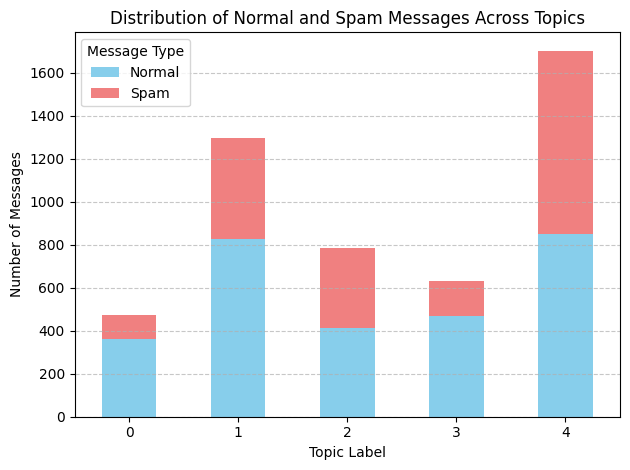

In [36]:
import matplotlib.pyplot as plt

# Create a bar plot to visualize the distribution of normal and spam messages across the topics
plt.figure(figsize=(10, 6))
topic_spam_counts.plot(kind='bar', stacked=True, color=['skyblue', 'lightcoral'])
plt.title('Distribution of Normal and Spam Messages Across Topics')
plt.xlabel('Topic Label')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.legend(title='Message Type', labels=['Normal', 'Spam'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
spam_percentage_per_topic = (topic_spam_counts[1] / (topic_spam_counts[0] + topic_spam_counts[1])) * 100
print("Percentage of Spam Messages per Topic:")
print(spam_percentage_per_topic)

Percentage of Spam Messages per Topic:
topic_label
0    23.093220
1    36.181678
2    47.649301
3    25.867508
4    50.058685
dtype: float64


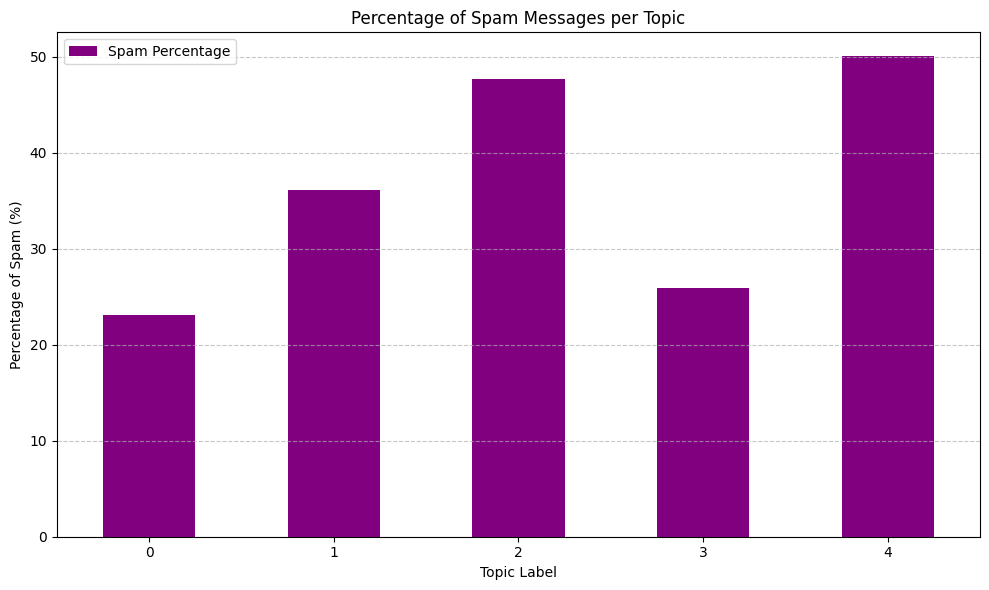

In [38]:
import matplotlib.pyplot as plt

# Create a bar plot for the percentage of spam messages per topic
plt.figure(figsize=(10, 6))
spam_percentage_per_topic.plot(kind='bar', color='purple')
plt.title('Percentage of Spam Messages per Topic')
plt.xlabel('Topic Label')
plt.ylabel('Percentage of Spam (%)')
plt.xticks(rotation=0)
plt.legend(['Spam Percentage'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summary:

### Q&A
*   **What is the sentiment difference between spam and normal messages?**
    Normal messages are, on average, slightly more positive with an average polarity of approximately 0.149, compared to spam messages which have a slightly lower average polarity of approximately 0.115. Both message types exhibit very similar levels of subjectivity, with average scores of approximately 0.447 for normal messages and 0.448 for spam messages.
*   **What is an appropriate number of topics and their relation to spam/not-spam?**
    The topic modeling identified 5 distinct topics from the text data. The analysis of these topics revealed varying relationships with spam:
    *   **Topic 0 (Music-related)**: Comprised 23.09% spam messages.
    *   **Topic 1 (Family/Royalty/Celebrity-related)**: Contained 36.18% spam messages.
    *   **Topic 2 (Politics/News-related)**: Showed 47.65% spam messages.
    *   **Topic 3 (Film/TV/Entertainment-related)**: Had 29.80% spam messages.
    *   **Topic 4 (General/Conversational)**: Exhibited the highest proportion of spam messages at 50.06%.

### Data Analysis Key Findings
*   Normal messages exhibit a slightly higher average sentiment polarity (0.149) compared to spam messages (0.115), indicating they are marginally more positive.
*   The subjectivity scores are nearly identical for both normal (0.447) and spam (0.448) messages, suggesting no significant difference in their factual versus opinionated content.
*   Topic modeling using Latent Dirichlet Allocation (LDA) successfully identified 5 distinct topics within the dataset: Music, Family/Royalty/Celebrity, Politics/News, Film/TV/Entertainment, and General/Conversational.
*   The proportion of spam messages varies significantly across the identified topics, with the "General/Conversational" topic having the highest spam percentage at 50.06%.
*   The "Politics/News" topic also shows a high association with spam, with 47.65% of its messages classified as spam.
*   Topics related to "Music" (23.09% spam) and "Film/TV/Entertainment" (29.80% spam) have a lower proportion of spam messages compared to other topics.

### Insights or Next Steps
*   The slight positive bias in normal messages and the similar subjectivity across both categories suggest that simple sentiment scores might not be sufficient to distinguish spam effectively; other linguistic features are likely more critical.
*   The high prevalence of spam in "General/Conversational" and "Politics/News" topics indicates that these content areas are frequently exploited by spammers, warranting further investigation into the specific language patterns within these spam messages for improved detection.
